In [1]:
import pandas as pd
import torch

from rdkit import Chem

from wombat.mpnn import mol_to_torch
from wombat.visualisation import visualize_atom_importance_from_mol
from wombat.ground_truth.highlight_smarts import highlight_atoms_in_mol, visualize_smarts_match
from wombat.krfp_models import krfp_models
from wombat.xai_methods import IGAttributionMethod, GNNExplainerAttributionMethod, PGExplainerAttributionMethod, \
    InputXGradientAttributionMethod
from wombat.xai_methods.captum_attributions import ShapleyValueSamplingAttributionMethod
from wombat.xai_methods.subgraph_x_attributions import SubgraphXAttributionMethod

In [2]:
df = pd.read_parquet("../wombat-smiles/validation_datasets/Pattern 4/validation_molecules.parquet")
df = df[df["ORIGIN"] == "POSITIVE"]

df

,SMILES,MoleculeGDetector,ORIGIN
0,Br.CCN(CC)CCOC(=O)C(Cc1ccc(N(CCCl)CCCl)cc1)NC(...,True,POSITIVE
1,CCN(CC)CCOC(=O)C(Cc1ccc(N(CCCl)CCCl)cc1)NC(C)=O,True,POSITIVE
2,CCN(CC)CCOC(=O)C(C)c1ccc(-c2ccccc2)c(F)c1,True,POSITIVE
3,CCN(CC)CCOC(=O)C1CCC(C#N)(c2ccc(OC)c(OC3CCCC3)...,True,POSITIVE
4,CC(=O)O.CCN(CC)CCOC(=O)C(C)c1cccc(Oc2ccccc2)c1,True,POSITIVE
...,...,...,...
1141,CC[NH+](CC)CCOC(=O)C1c2ccccc2Oc2ccccc21,True,POSITIVE
1142,CC[NH+](CC)CCOC(=O)C(Cc1cccc2ccccc12)Cc1cccc2c...,True,POSITIVE
1143,CCN(CC)CCOC(=O)C(Cc1ccc(-c2c(C)n(C)c(=O)n(C)c2...,True,POSITIVE
1144,CCN(CC)CCOC(=O)C(C)c1ccc(Br)cc1,True,POSITIVE


In [3]:
example_smiles = df.iloc[0]["SMILES"]
example_mol = Chem.MolFromSmiles(example_smiles)

model, smarts_pre, smarts_post = krfp_models[3]
model_name = model.__class__.__name__
publication_name = model_name_to_publication_name[model_name]

In [4]:
x, edge_index, edge_features = mol_to_torch(example_mol)

In [5]:
ig_explainer = IGAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, _ = ig_explainer.explain(x, edge_features, edge_index)
atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()

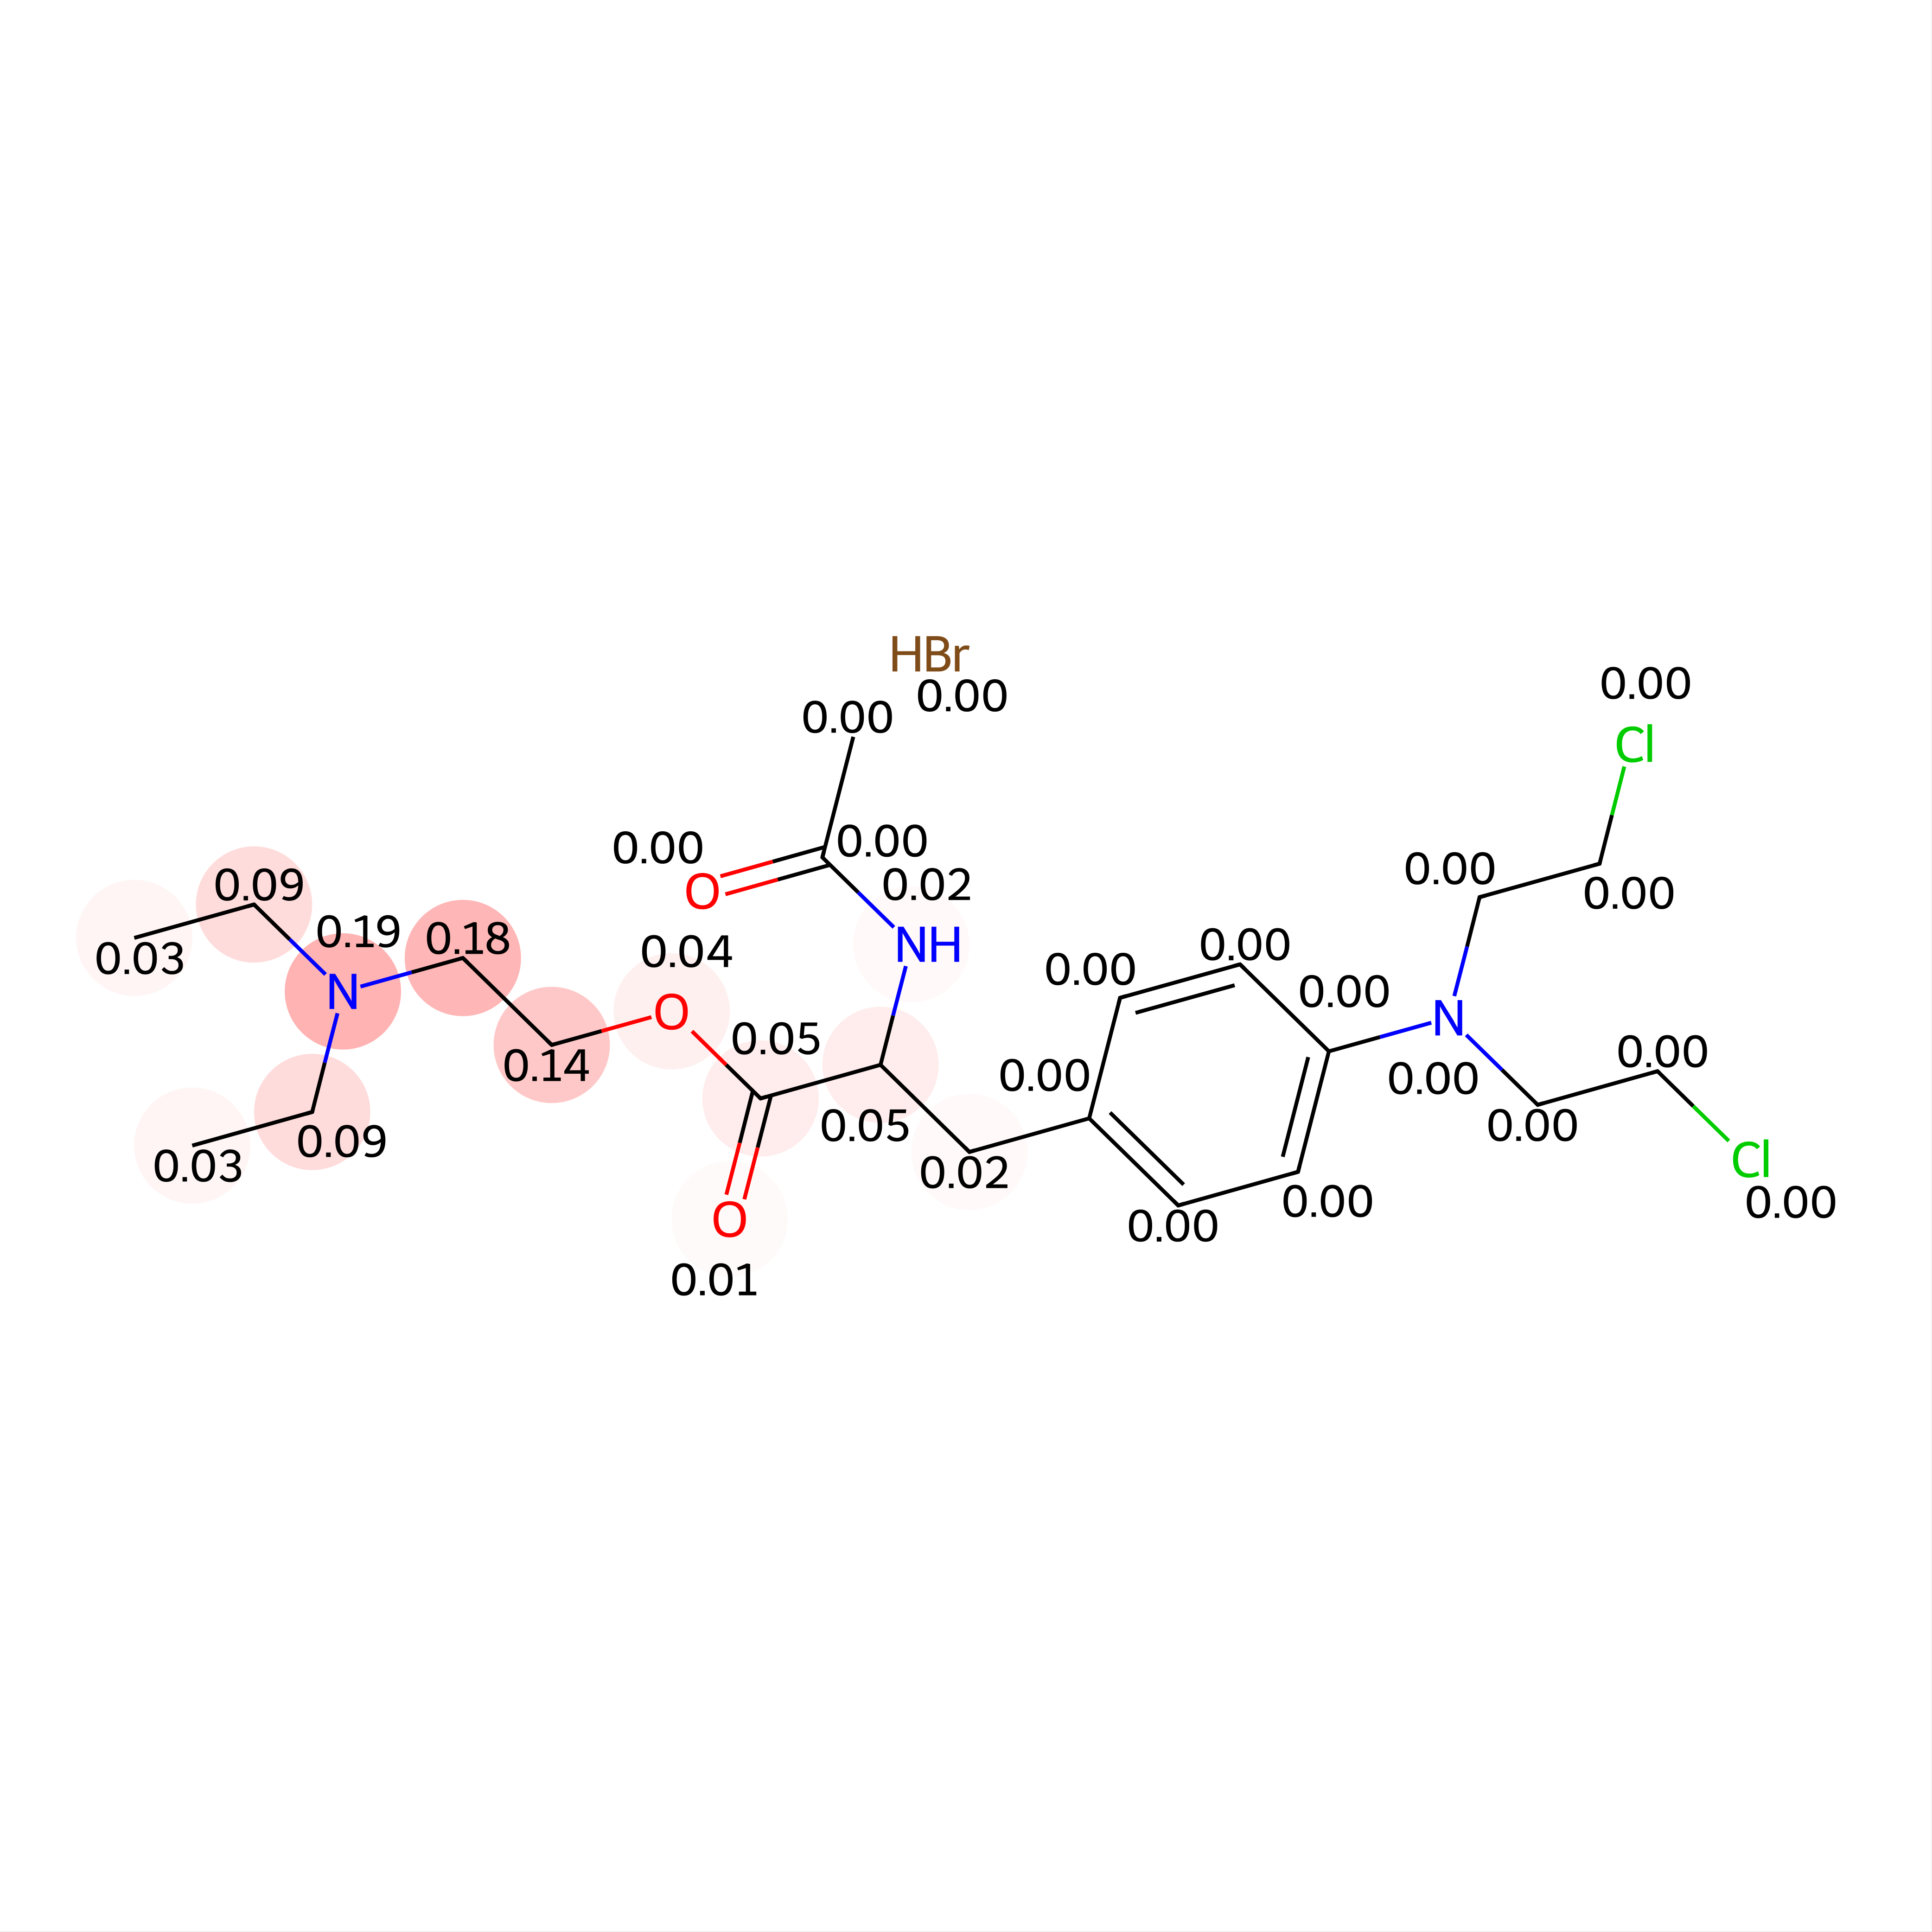

In [6]:
img = visualize_atom_importance_from_mol(
    example_mol,
    atom_importance,
    length=1000,
)

img

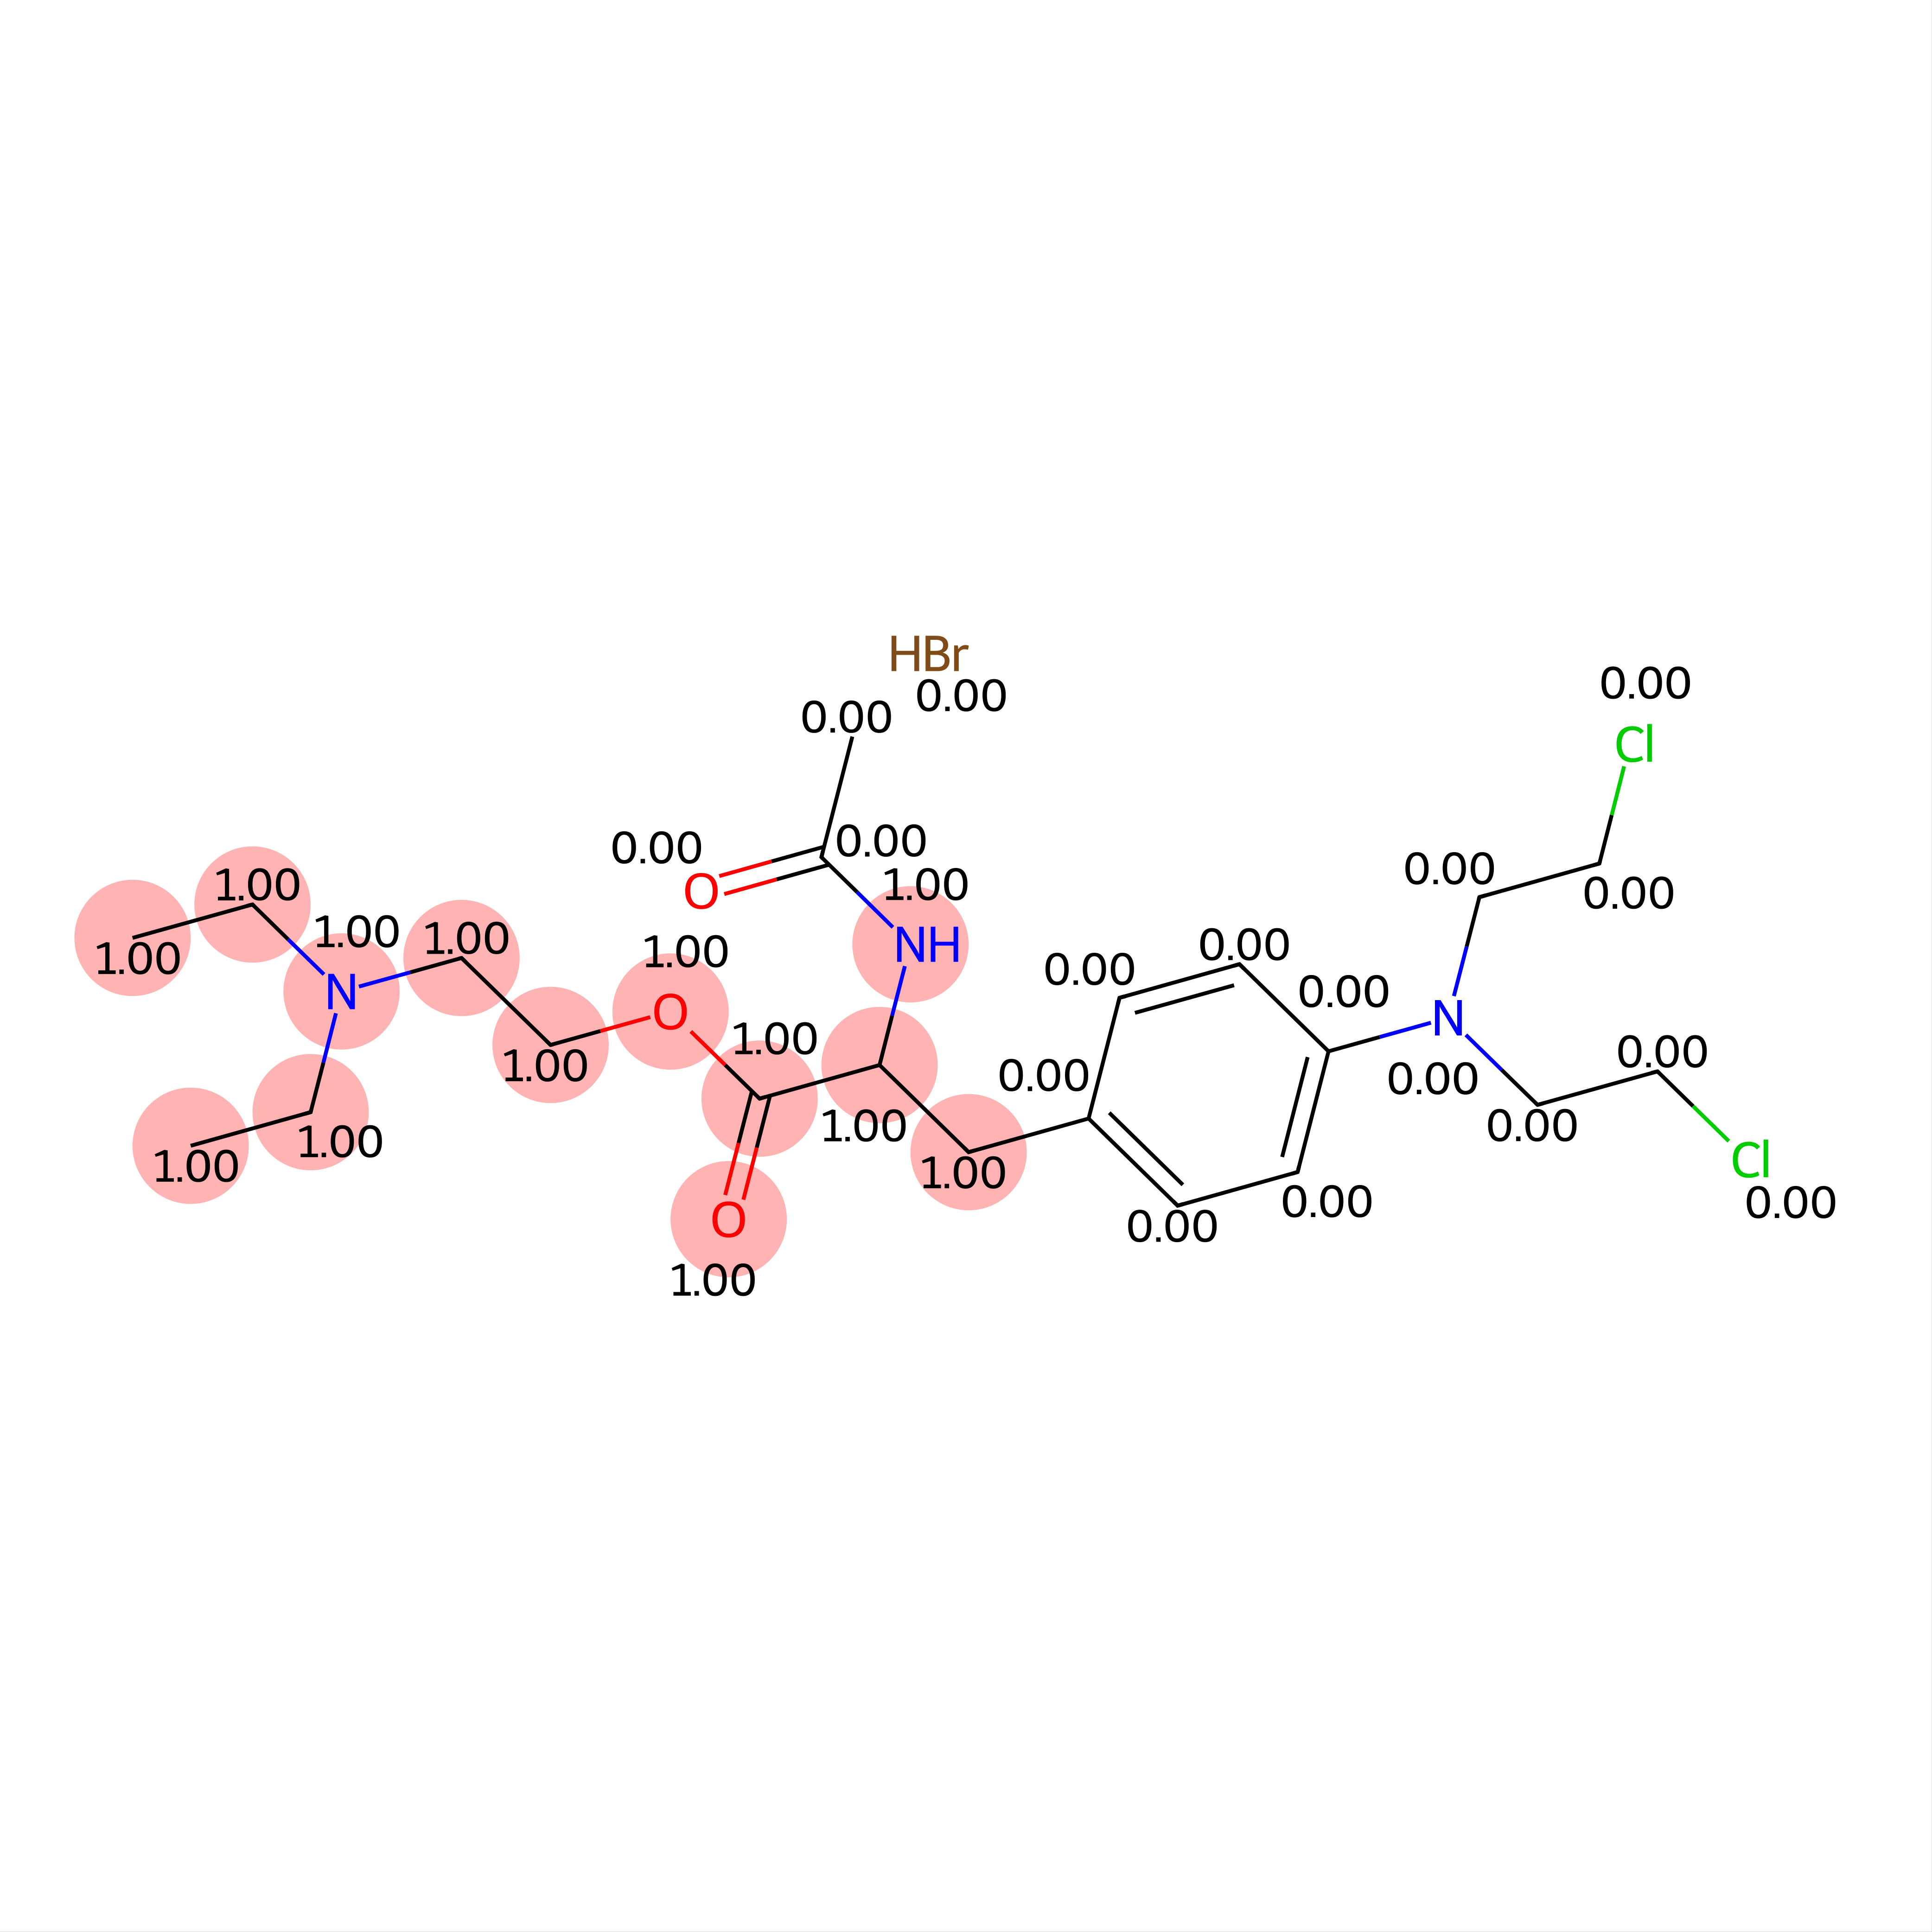

In [7]:
baseline_img = visualize_smarts_match(
    example_mol,
    smarts_post,
)

baseline_img

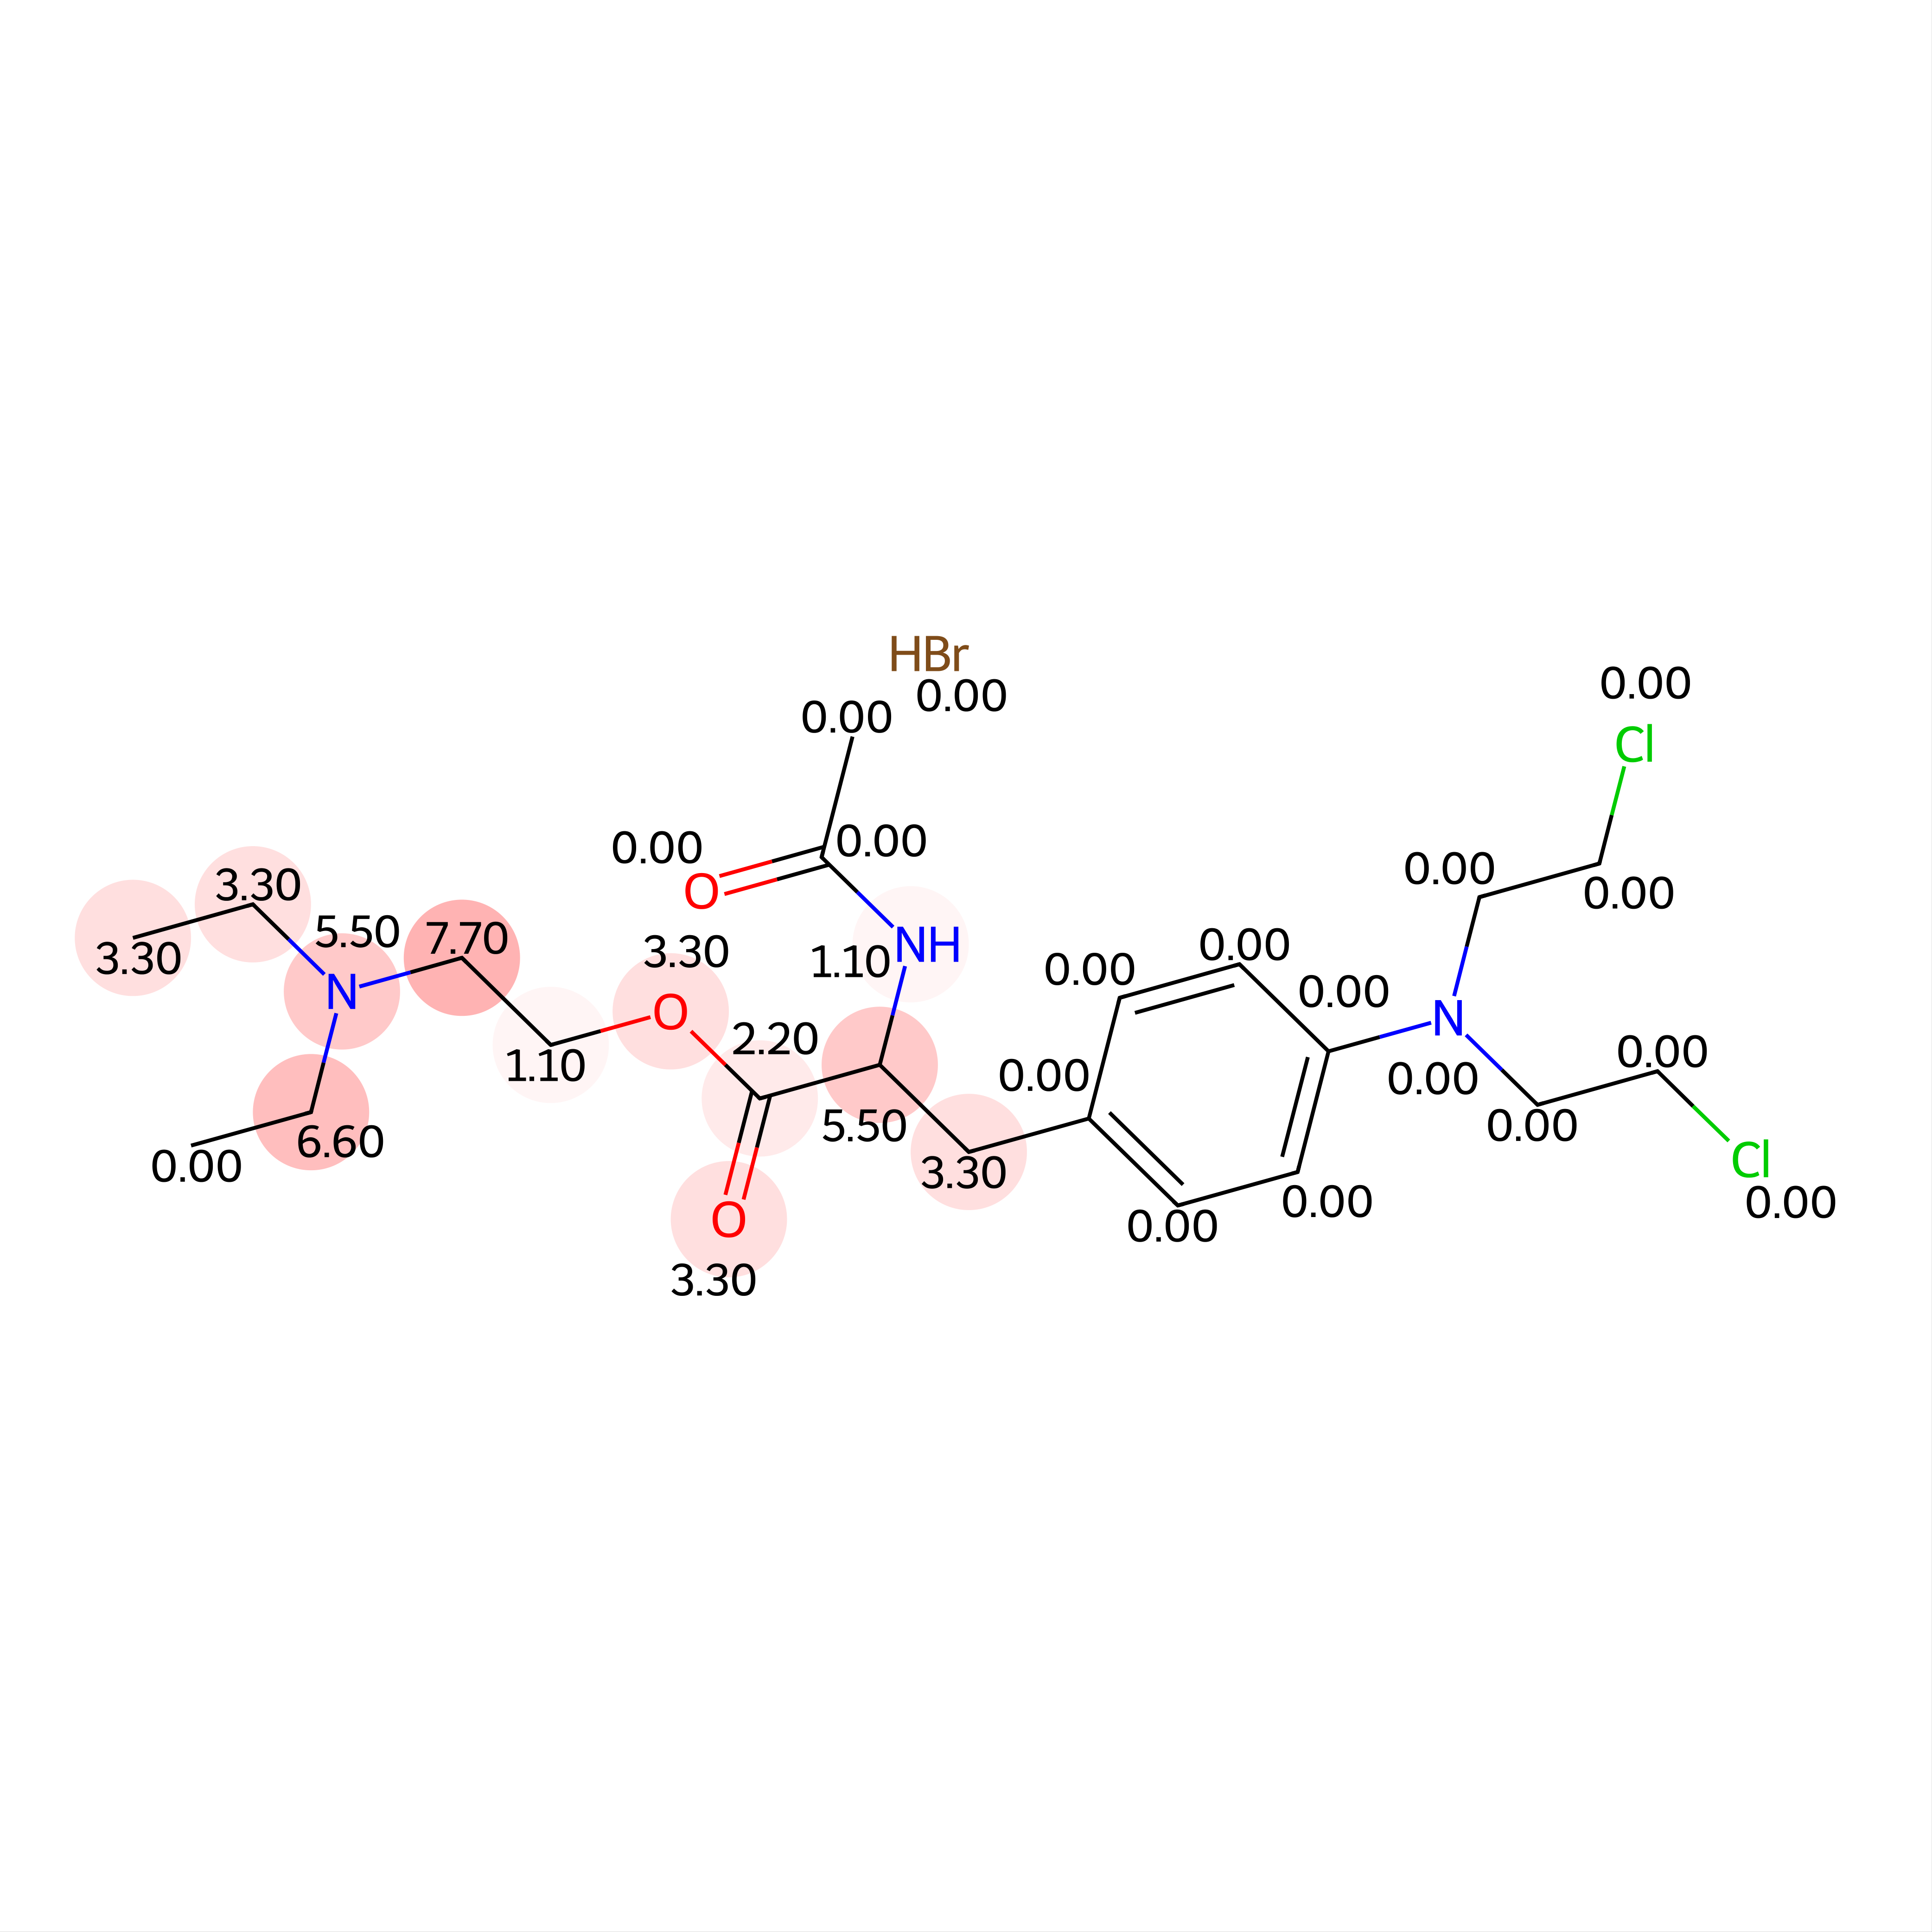

In [8]:
shapley_explainer = ShapleyValueSamplingAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

shapley_atom_importance, _ = shapley_explainer.explain(x, edge_features, edge_index)
shapley_atom_importance = torch.sum(torch.abs(shapley_atom_importance), dim=1).cpu().numpy().tolist()

shapley_img = visualize_atom_importance_from_mol(
    example_mol,
    shapley_atom_importance,
    length=1000,
)
shapley_img

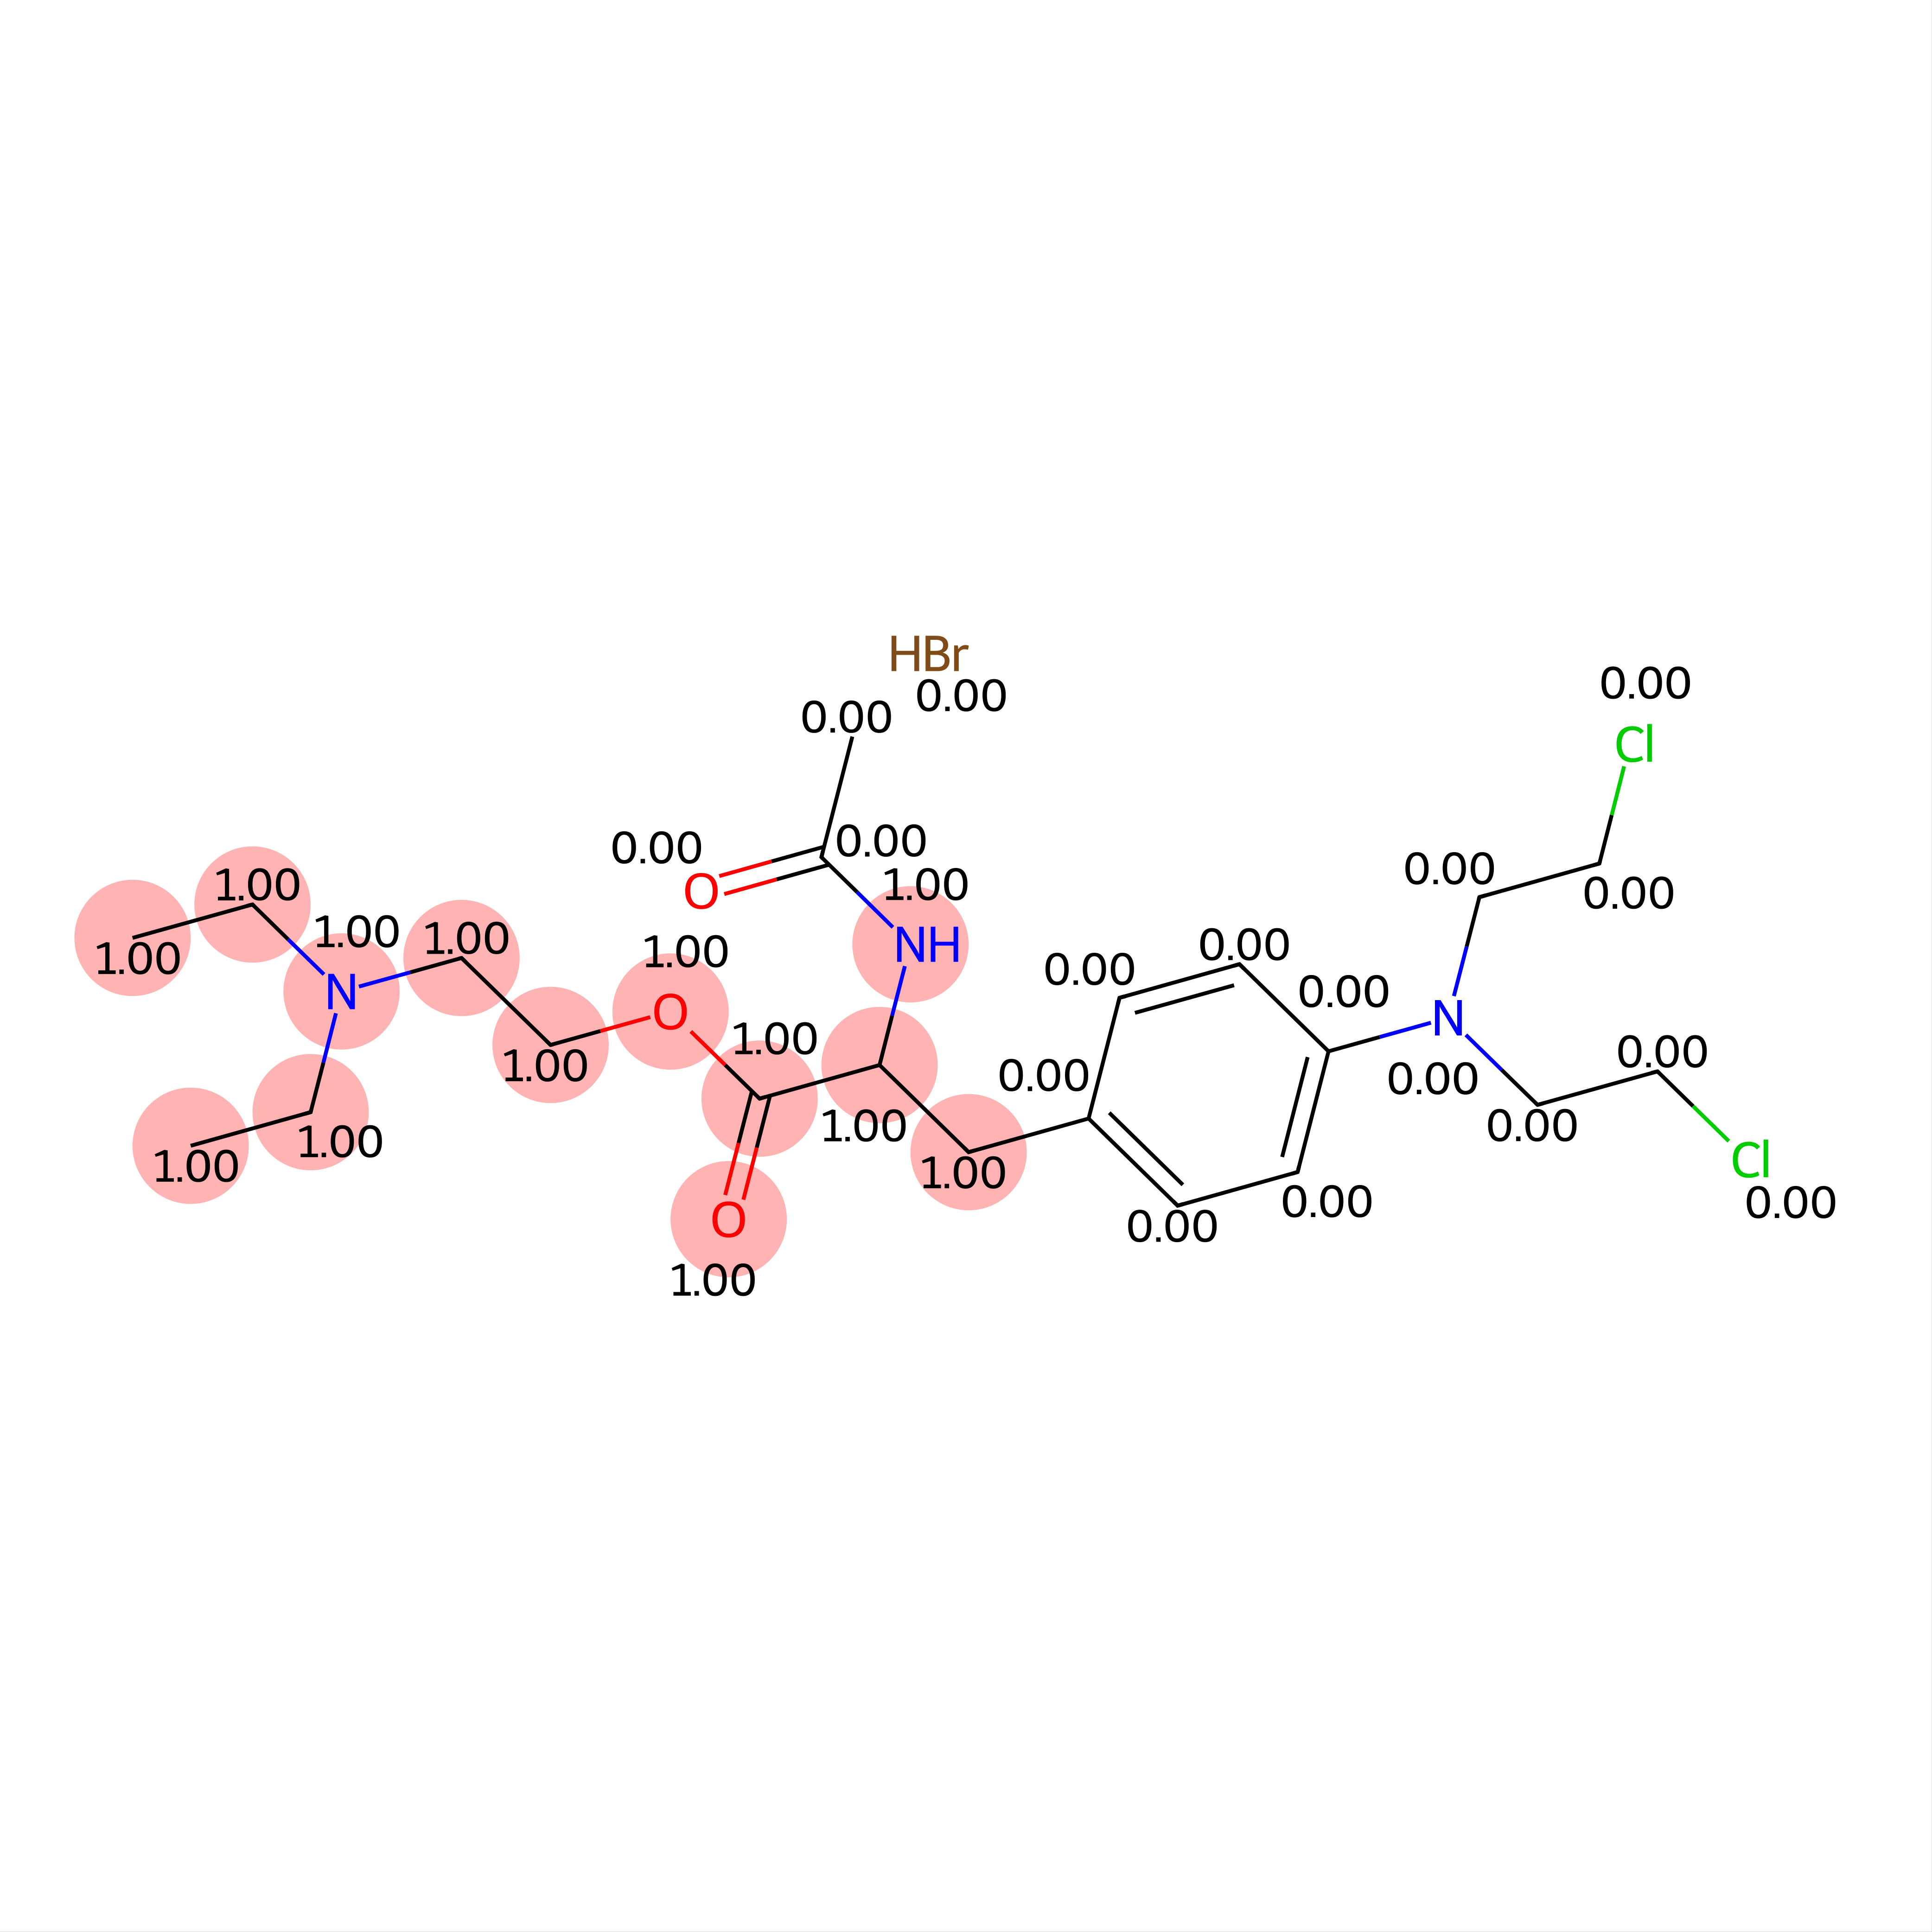

In [9]:
subgraph_x_explainer = SubgraphXAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

subgraph_x_atom_importance, _ = subgraph_x_explainer.explain(x, edge_features, edge_index)
subgraph_x_atom_importance = torch.sum(torch.abs(subgraph_x_atom_importance), dim=1).cpu().numpy().tolist()

subgraph_x_img = visualize_atom_importance_from_mol(
    example_mol,
    subgraph_x_atom_importance,
    length=1000,
)
subgraph_x_img

/home/dominik/MyStuff/wombat-gmum/.venv/lib/python3.12/site-packages/torch_geometric/explain/algorithm/base.py:192: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(y_hat, y)


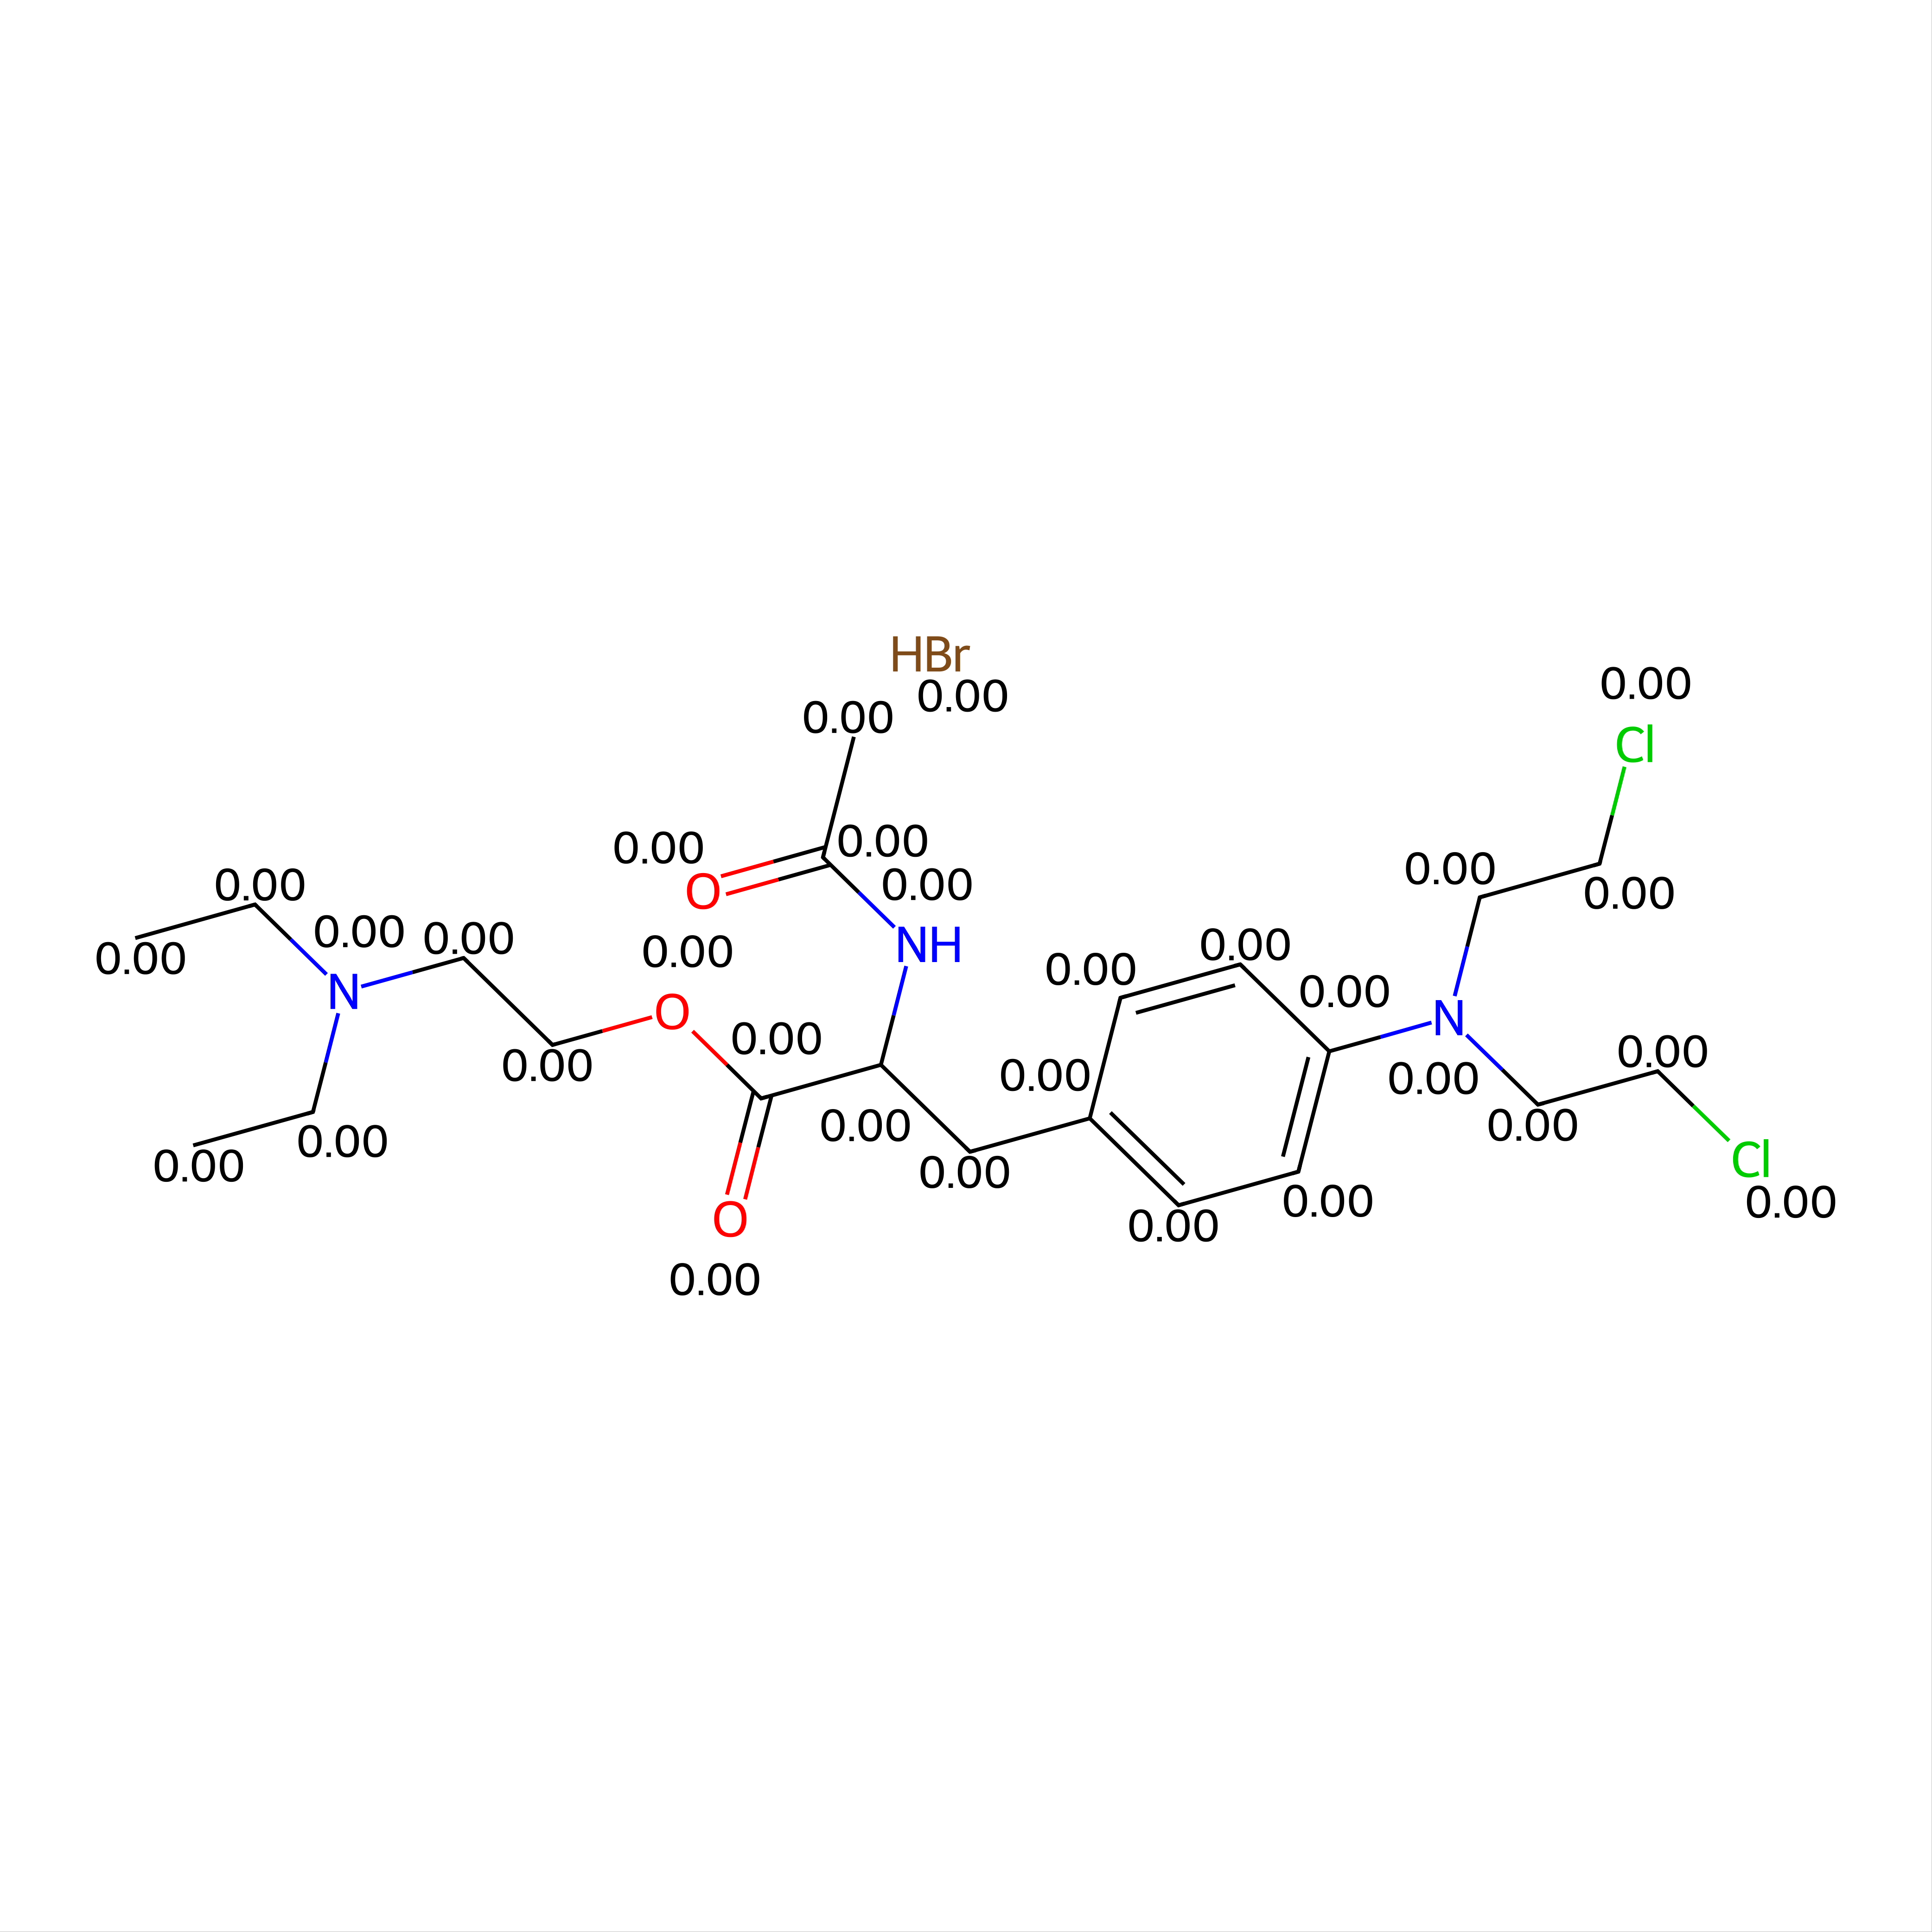

In [10]:
saliency_explainer = GNNExplainerAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

saliency_atom_importance, _ = saliency_explainer.explain(x, edge_features, edge_index)
saliency_atom_importance = torch.sum(torch.abs(saliency_atom_importance), dim=1).cpu().numpy().tolist()

saliency_img = visualize_atom_importance_from_mol(
    example_mol,
    saliency_atom_importance,
    length=1000,
)
saliency_img

/home/dominik/MyStuff/wombat-gmum/.venv/lib/python3.12/site-packages/torch_geometric/explain/algorithm/base.py:192: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(y_hat, y)


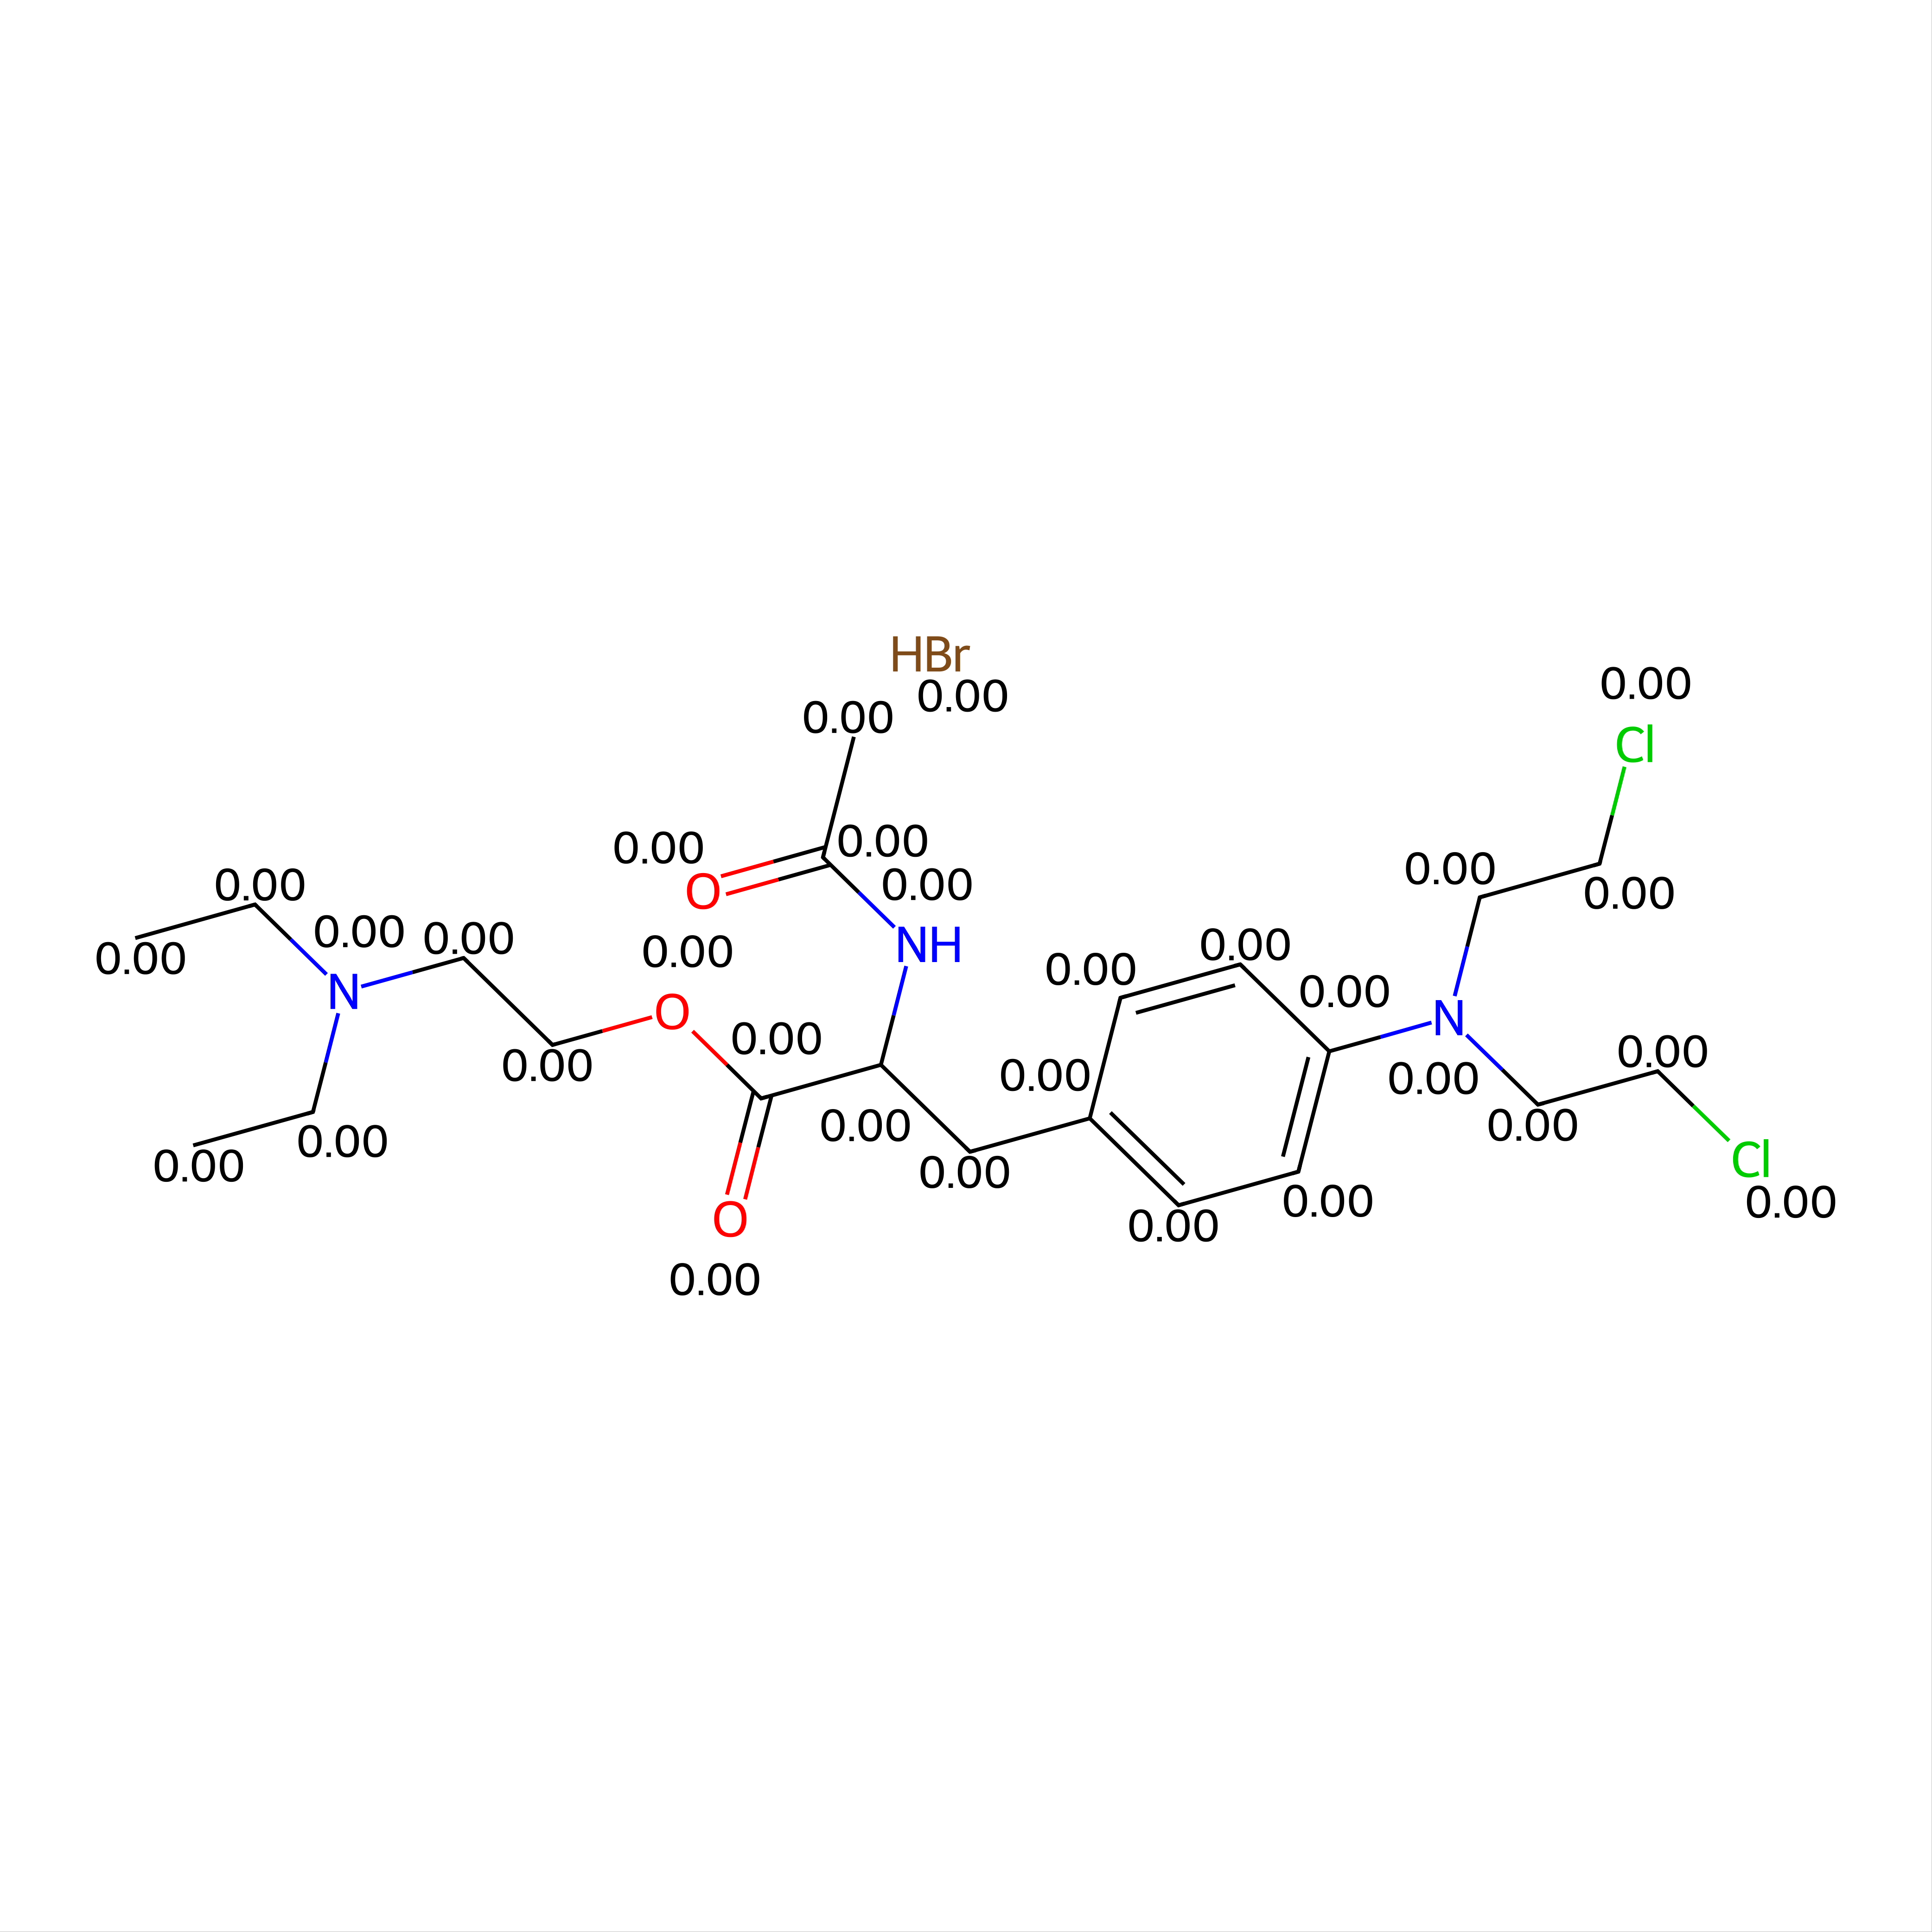

In [11]:
gnn_explainer = GNNExplainerAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

gnn_explainer_attribution, _ = gnn_explainer.explain(x, edge_features, edge_index)
gnn_explainer_atom_importance = torch.sum(torch.abs(gnn_explainer_attribution), dim=1).cpu().numpy().tolist()

gnn_explainer_img = visualize_atom_importance_from_mol(
    example_mol,
    gnn_explainer_atom_importance,
    length=1000,
)
gnn_explainer_img

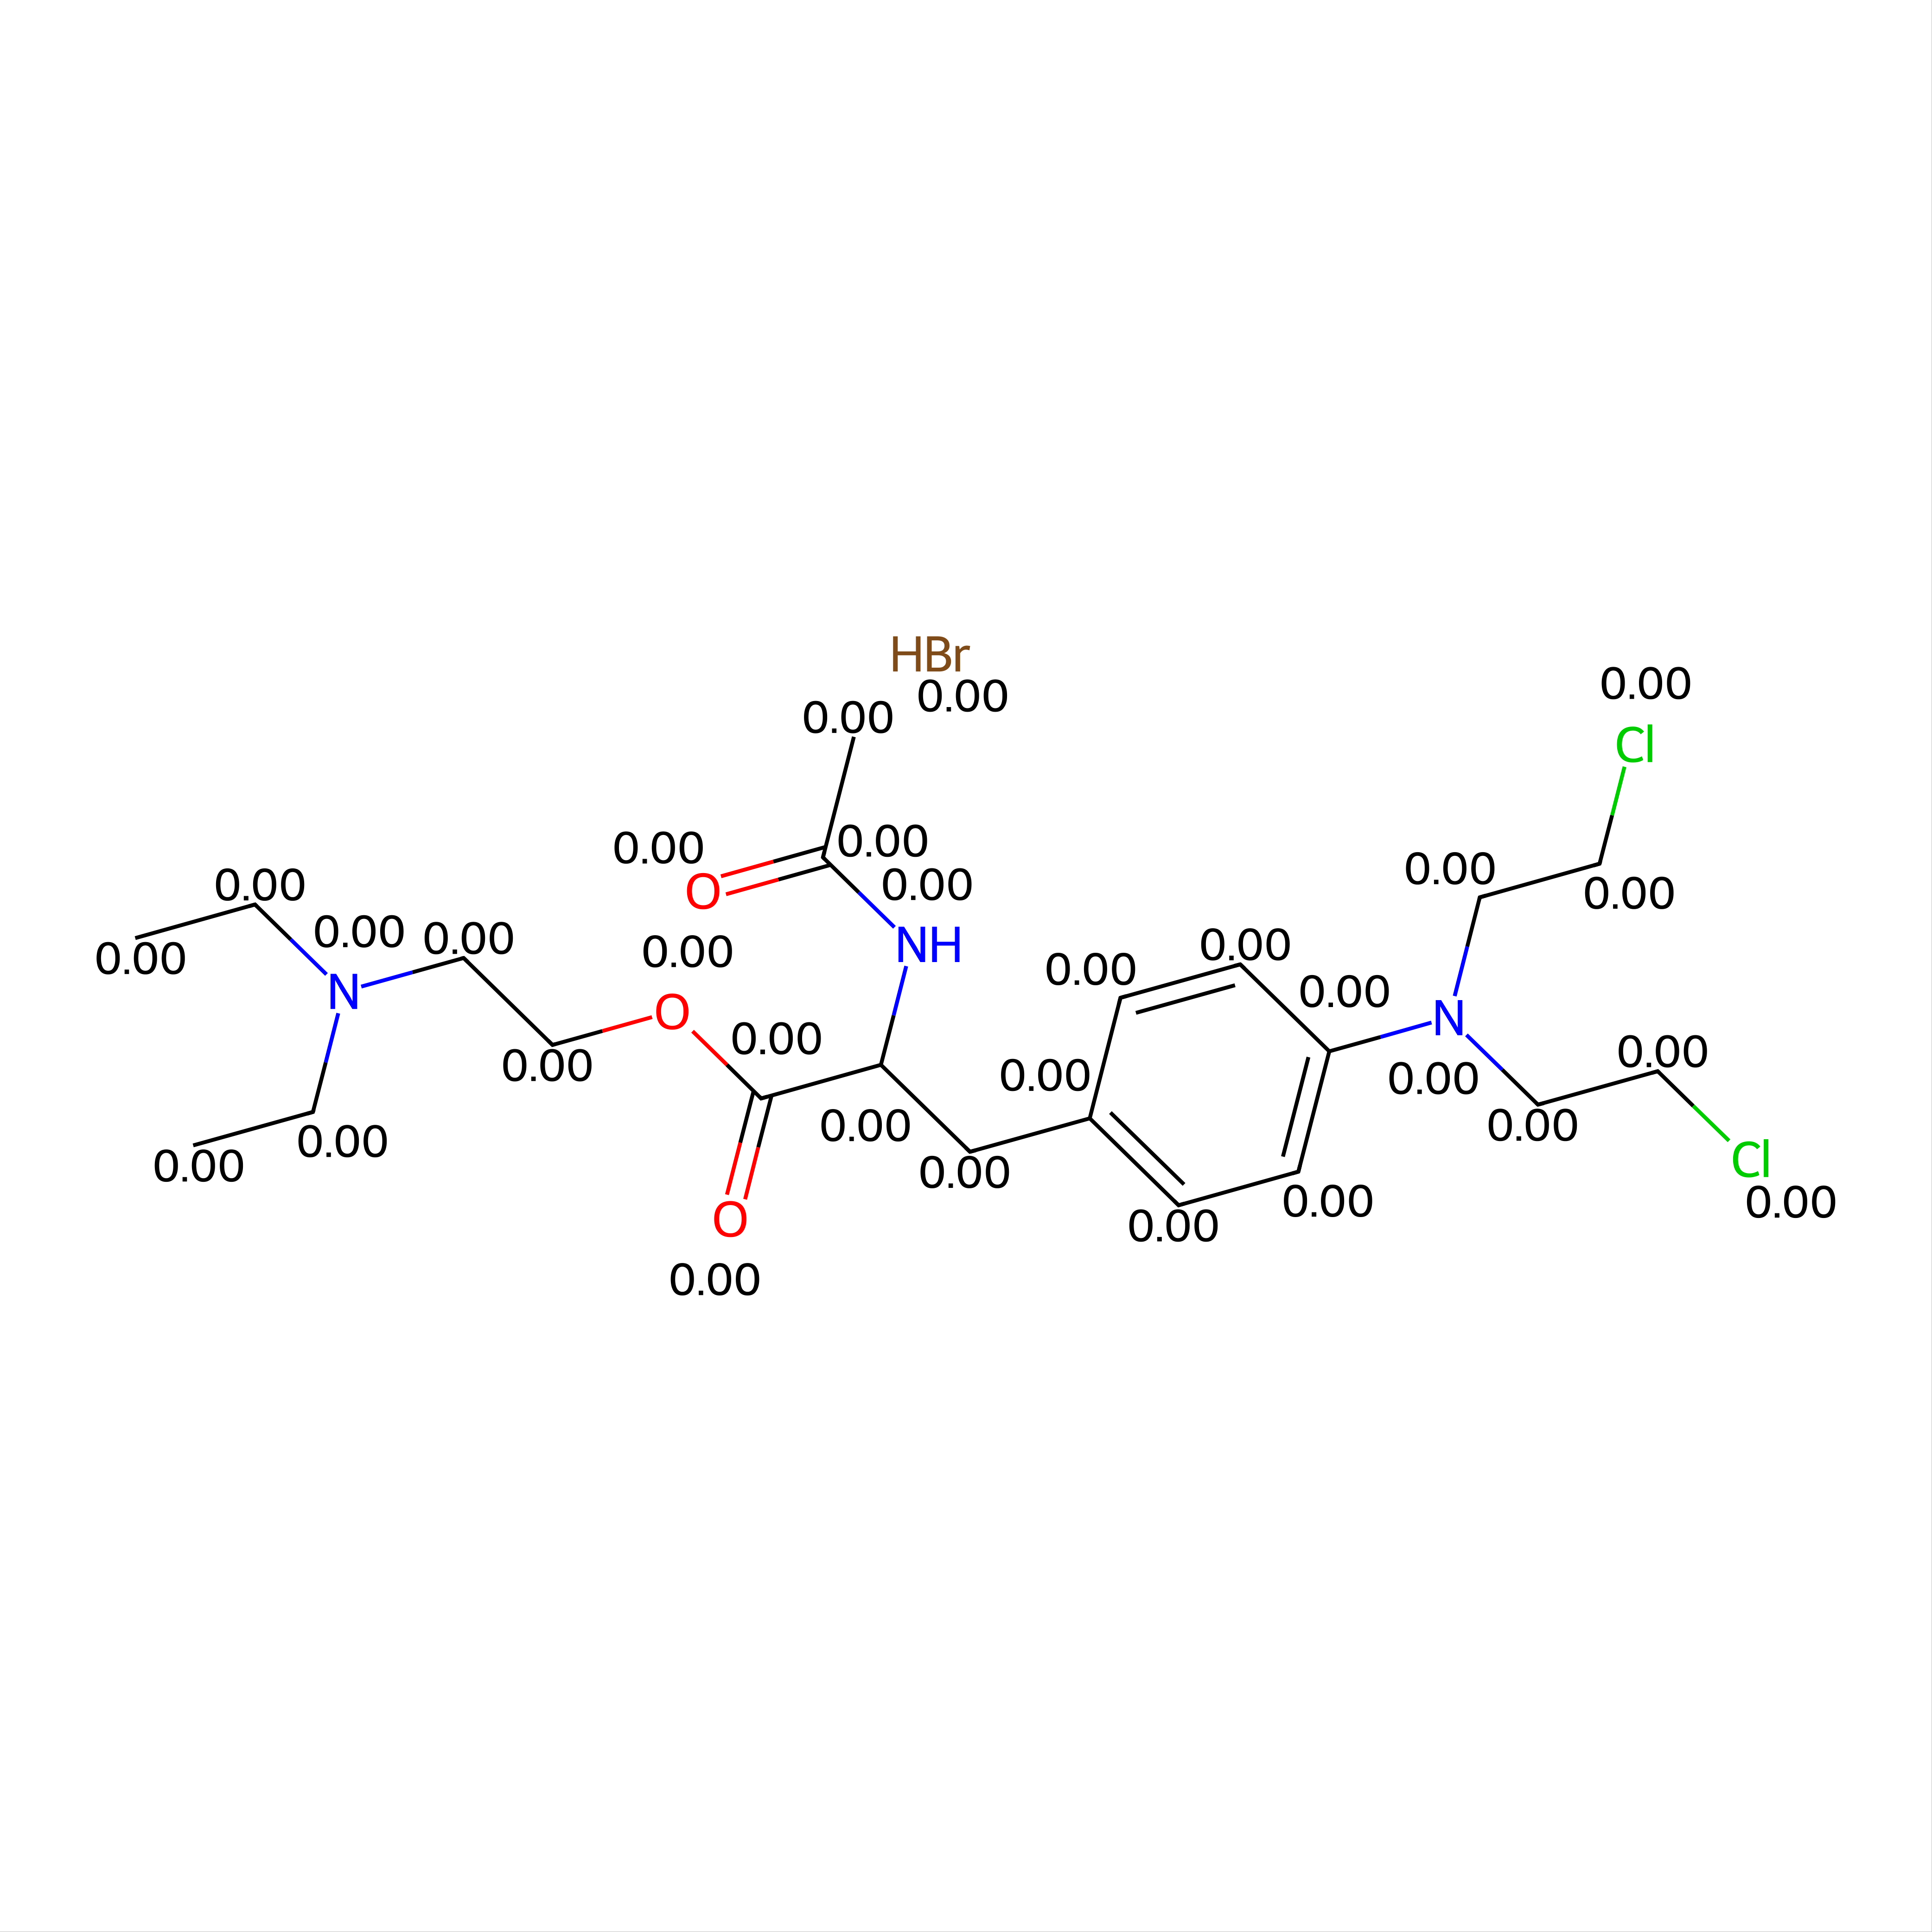

In [12]:
pg_explainer = torch.load(
    "../artifacts/explainability_method_tester/R2/MoleculeGDetector/PG Explainer_explainer.pt",
    weights_only=False)

pg_explainer_attribution, _ = pg_explainer.explain(x, edge_features, edge_index)
pg_explainer_atom_importance = torch.sum(torch.abs(pg_explainer_attribution), dim=1).cpu().numpy().tolist()

pg_explainer_img = visualize_atom_importance_from_mol(
    example_mol,
    pg_explainer_atom_importance,
    length=1000,
)
pg_explainer_img

/home/dominik/MyStuff/wombat-gmum/.venv/lib/python3.12/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/home/dominik/MyStuff/wombat-gmum/.venv/lib/python3.12/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 1 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


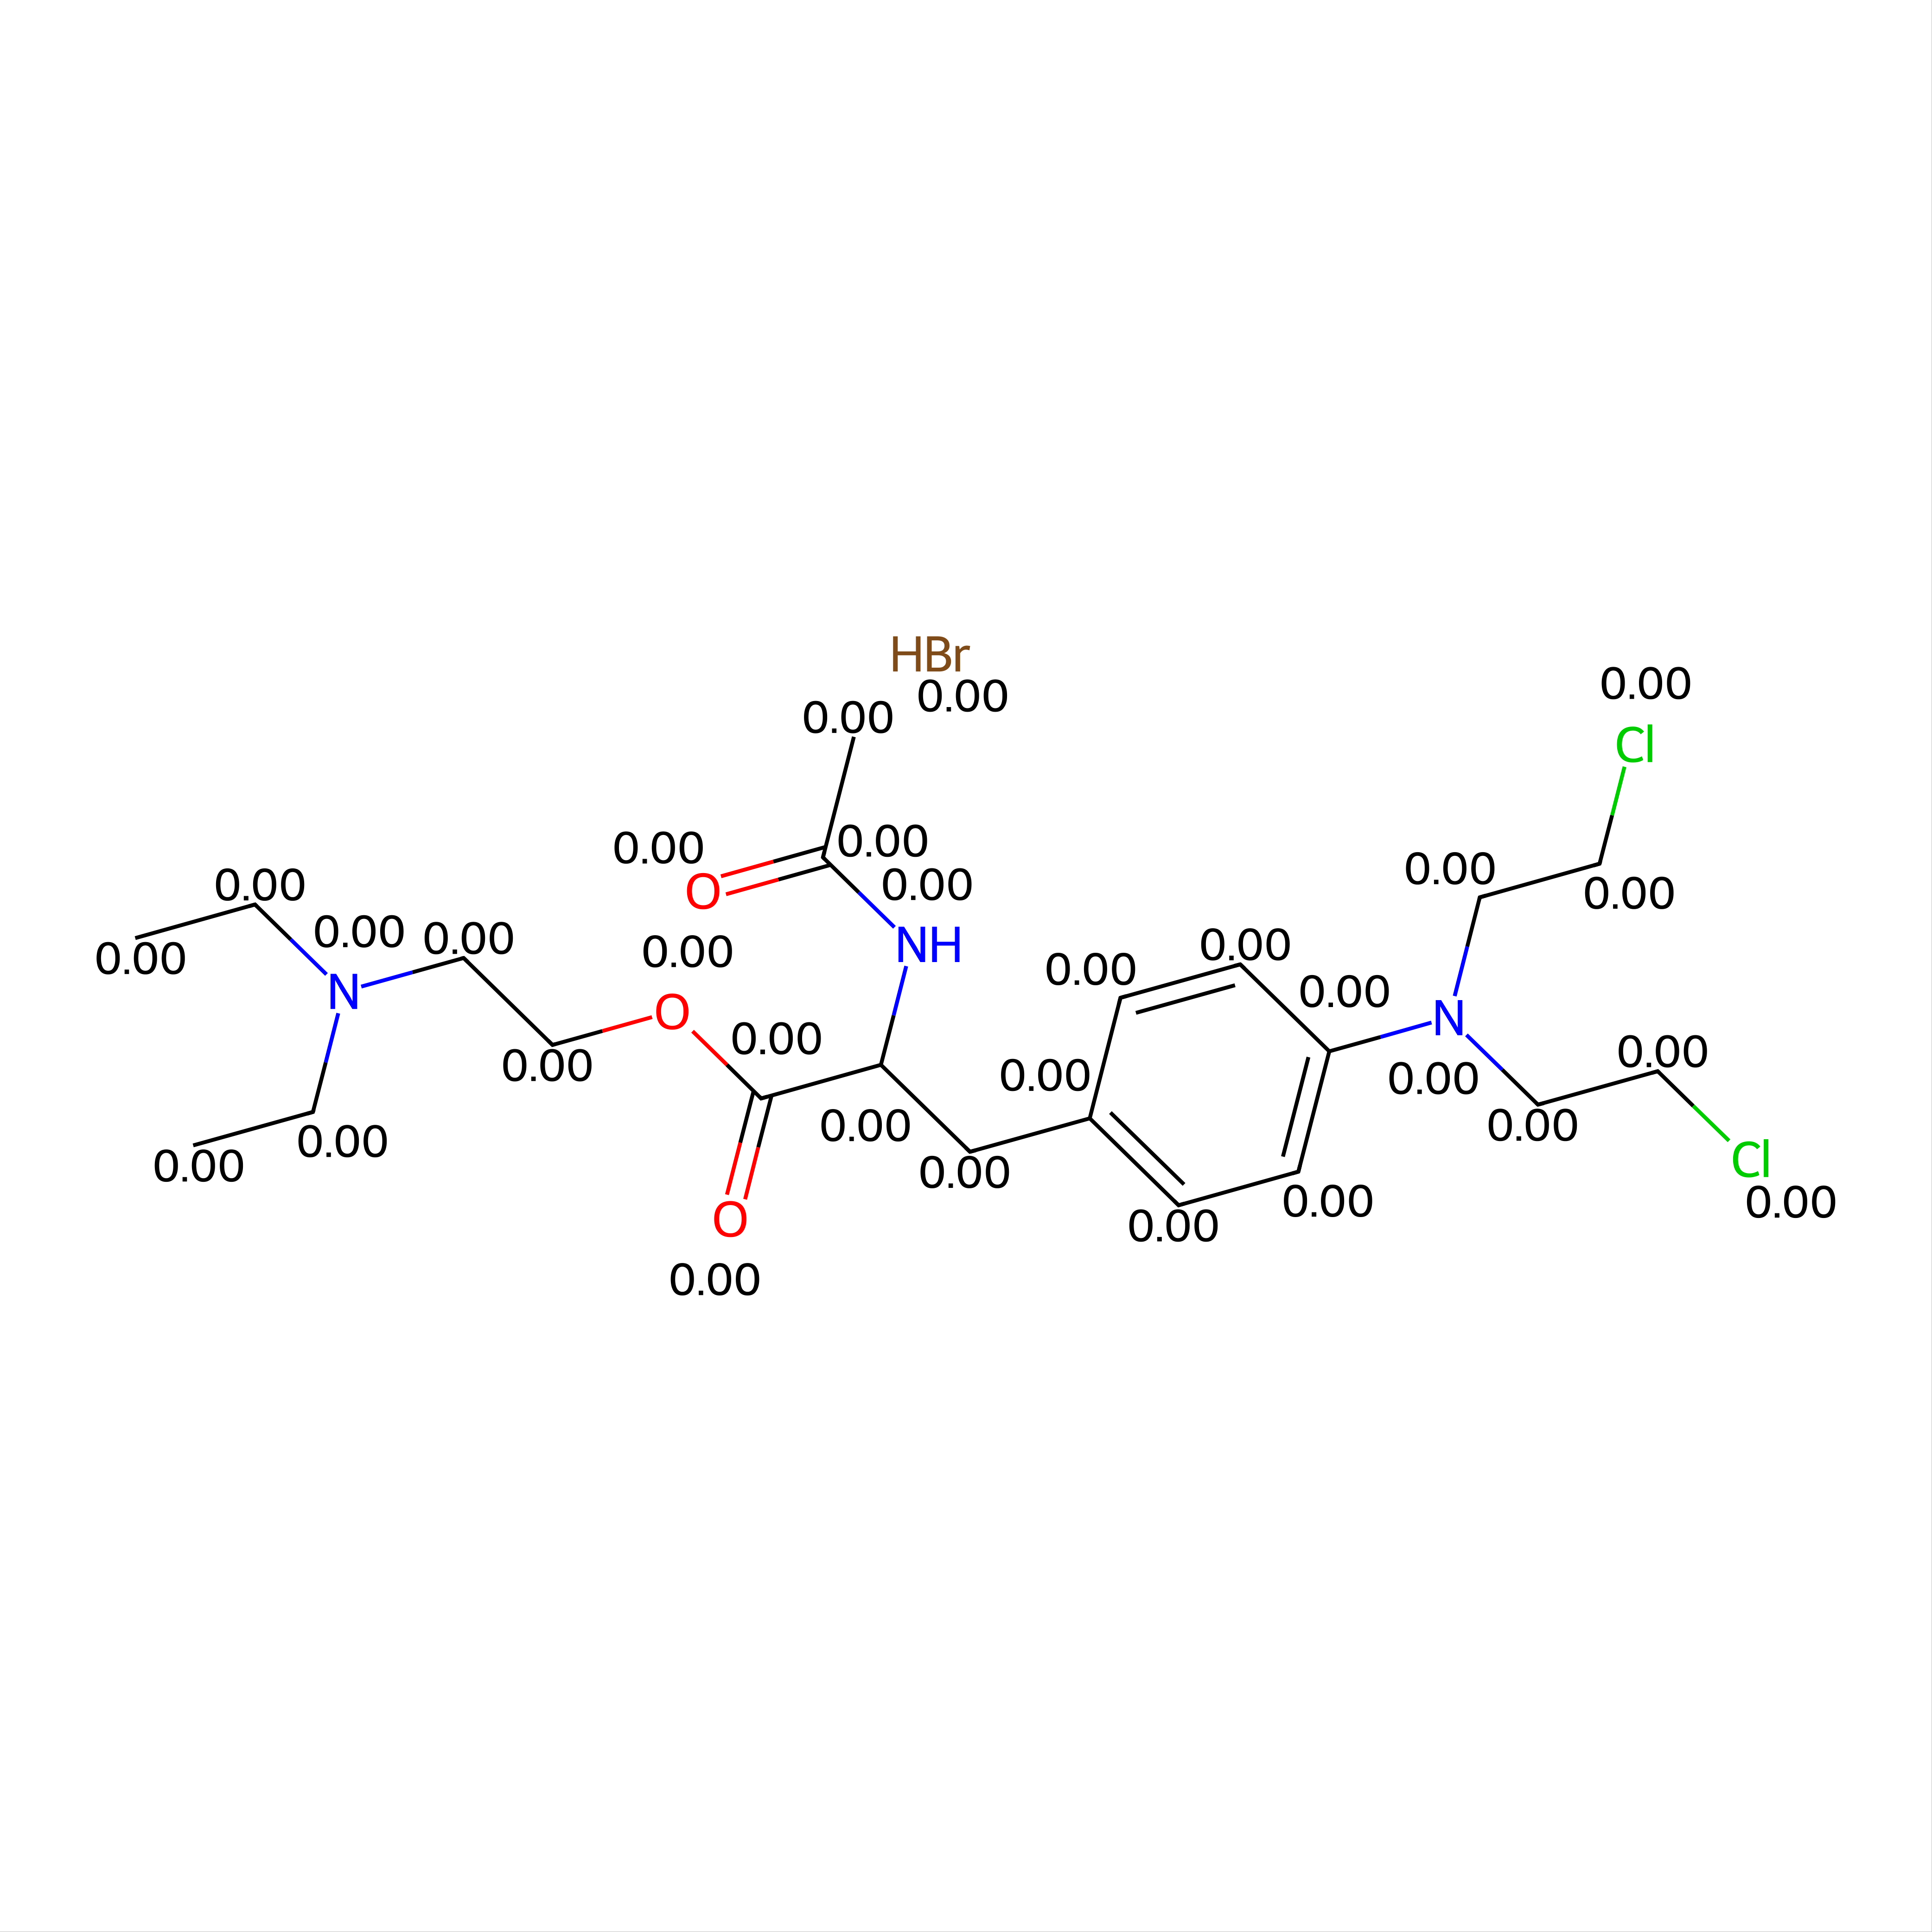

In [13]:
input_x_gradient_explainer = InputXGradientAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

input_x_gradient_attribution, _ = input_x_gradient_explainer.explain(x, edge_features, edge_index)
input_x_gradient_atom_importance = torch.sum(torch.abs(input_x_gradient_attribution),
                                             dim=1).cpu().detach().numpy().tolist()

input_x_gradient_img = visualize_atom_importance_from_mol(
    example_mol,
    input_x_gradient_atom_importance,
    length=1000,
)

input_x_gradient_img